In [1]:
import sys
sys.path.append("../")

from methods.Steepest_descent import (gradient_descent)
from methods.Error import (save_iterations, history, calculate_precision, plot_methods_error, ten_iterations)
from methods.Newton_method import (newton_method)
from methods.Conjugate_method import (conjugate_gradient)
import numpy as np
import os
import matplotlib.pyplot as plt

-----------------------------
Method:  Gradient_descent
Minimum point:  [3.21829795 3.21829795]
Function value at minimum:  28.964681538168893
Number of iterations:  303
-----------------------------


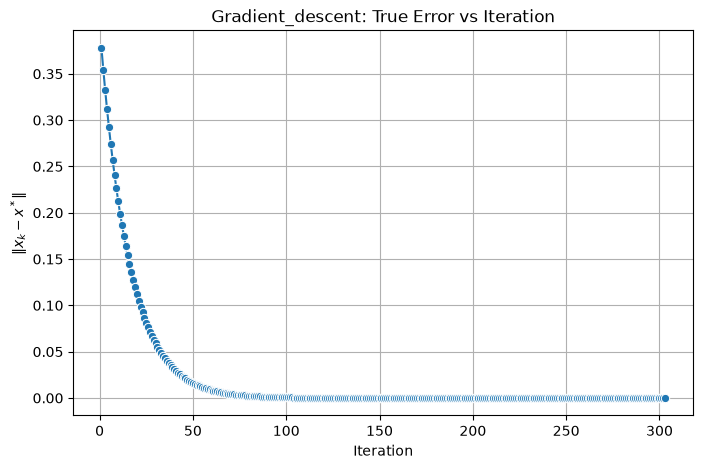

-----------------------------
Method:  Newton Method
Minimum point:  [3.21829795 3.21829795]
Function value at minimum:  28.96468153816889
Number of iterations:  9
-----------------------------


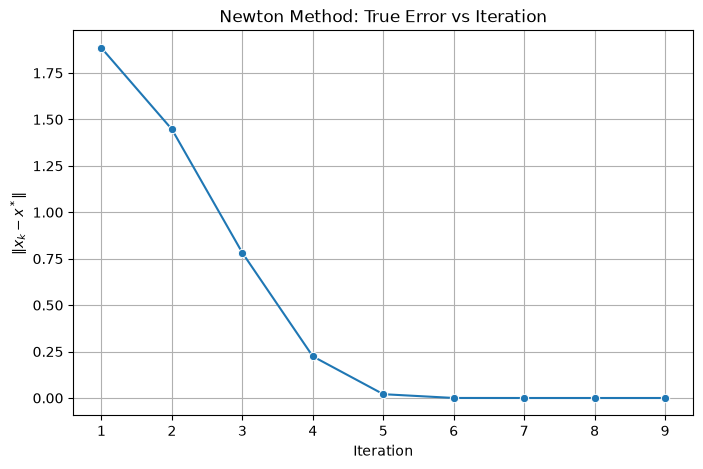

-----------------------------
Method:  Conjugate Gradient Method
Minimum point:  [-1501376.68723682 -1486341.05928342]
Function value at minimum:  -8963153.23956072
Number of iterations:  1000
-----------------------------


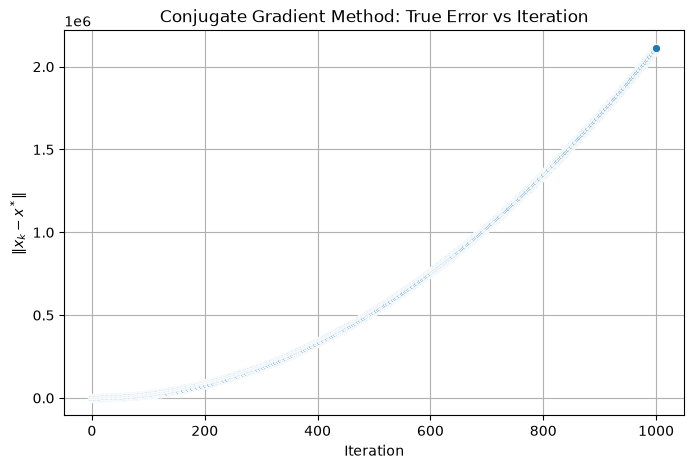

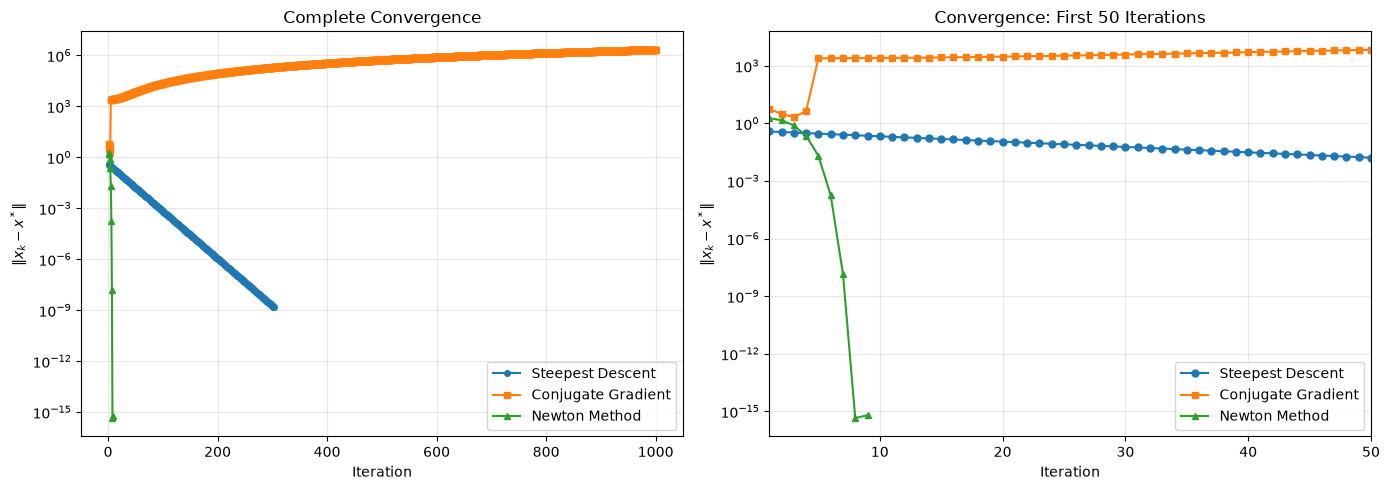

Plot saved: results\plots\methods_comparison_error.png
               Method  Iterations   Final Error  Correct Decimals
0    Steepest Descent         303  1.480213e-09                 8
1  Conjugate Gradient        1000  2.112667e+06                 0
2       Newton Method           9  6.280370e-16                14

Database saved: results\methods_precision.csv
                Method  iteration           x1         x2         f(x)  \
0     Steepest Descent          1     3.020559   3.540296    29.033889   
1     Steepest Descent          2     3.026947   3.516409    29.025047   
2     Steepest Descent          3     3.033860   3.494544    29.017433   
3     Steepest Descent          4     3.041120   3.474502    29.010847   
4     Steepest Descent          5     3.048580   3.456106    29.005132   
5     Steepest Descent          6     3.056126   3.439199    29.000157   
6     Steepest Descent          7     3.063663   3.423638    28.995816   
7     Steepest Descent          8     3.07

In [ ]:
import numpy as np

def f(x, y):
    # Set the constant used in the function
    d = 3
    # Calculate the objective function
    return 3 * x + 100 / (x * y) + d * y

def df_dx(x, y):
    # Set the constant used in the function
    d = 3
    # Calculate the partial derivative with respect to x
    return 3 - 100 / (x ** 2 * y)

def df_dy(x, y):
    # Set the constant used in the function
    d = 3
    # Calculate the partial derivative with respect to y
    return -100 / (x * y ** 2) + d

def gradient(x, y):
    # Combine both partial derivatives into the gradient vector
    return np.array([df_dx(x, y), df_dy(x, y)])

def hessian(x, y):
    # Build the Hessian matrix using the second partial derivatives
    return np.array([
        [200 / (x ** 3 * y), 100 / (x ** 2 * y ** 2)],
        [100 / (x ** 2 * y ** 2), 200 / (x * y ** 3)]
    ])

def printing(method, minimum, f_min, iterations):
    # Print the main results of the optimization method
    print("-----------------------------")
    print("Method: ", method)
    print("Minimum point: ", minimum)
    print("Function value at minimum: ", f_min)
    print("Number of iterations: ", iterations)
    print("-----------------------------")

# Set the initial point and convergence parameters
d = 3
x0 = np.array([1.0, 3.0])
tol = 1e-10
max_iter = 1000

# Define the exact solution to compare the results with
x_exact = np.array([(100 / 3) ** (1 / 3), (100 / 3) ** (1 / 3)])

# Set the step size for Steepest Descent
alpha = 0.06661185

# Main
if __name__ == "__main__":
    # Run Steepest Descent
    minimum, f_min, iterations, history_data = gradient_descent(x0, f, gradient, tol, max_iter, alpha, history)
    printing("Gradient_descent", minimum, f_min, iterations)
    df_gradient = save_iterations(history_data, "Gradient_descent", x_exact)

    # Run Newton's Method
    minimum, f_min, iterations, history_data = newton_method(x0, f, gradient, hessian, tol, max_iter, alpha, history)
    printing("Newton Method", minimum, f_min, iterations)
    df_newton = save_iterations(history_data, "Newton Method", x_exact)

    # Run Conjugate Gradient
    minimum, f_min, iterations, history_data = conjugate_gradient(x0, f, gradient, tol, max_iter, history)
    printing("Conjugate Gradient Method", minimum, f_min, iterations)
    df_conjugate = save_iterations(history_data, "Conjugate Gradient Method", x_exact)

    # Set the folder where the results will be saved
    results_path = "results"

    # Plot and compare the error of all methods
    plot_methods_error(results_path)

    # Calculate the final precision of each method
    calculate_precision(results_path)

    # Create a table containing the first 10 iterations
    ten_iterations(results_path)